# MSDS670_X40_Data Visualization
## 2026 Spring 8 Week 1
## Week 8 - Final Project

---

### Author: Ilse Severance

In [1]:
#Loading libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from matplotlib.ticker import StrMethodFormatter
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import geopandas as gpd
from shapely.geometry import Point
from matplotlib.colors import LinearSegmentedColormap
#Remove warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
#Importing the data
df = pd.read_csv('wildfire_multi_region_dataset.csv')
df.head()

,latitude,longitude,acq_date,acq_time,year,month,season,daynight,region,country,...,satellite,instrument,brightness_k,frp_mw,fire_intensity,confidence,temp_max_c,wind_max_kmh,precip_mm,humidity_pct
0,-16.7722,151.0241,1/1/2024,1133,2024,1,Summer,D,Australia,Australia,...,TERRA,MODIS,347.72,29.38,Moderate,high,42.1,1.7,0.47,18.4
1,-41.1960,130.1397,1/1/2024,1251,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,357.82,62.05,High,nominal,43.8,2.2,0.27,11.7
2,-39.8750,124.9104,1/2/2024,1326,2024,1,Summer,D,Australia,Australia,...,Suomi-NPP,VIIRS,333.76,3.35,Low,high,35.4,4.4,0.35,5.0
3,-10.0978,149.8371,1/2/2024,206,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,323.94,46.35,Moderate,high,39.6,34.7,0.30,39.1
4,-12.4540,119.2301,1/2/2024,2054,2024,1,Summer,N,Australia,Australia,...,Suomi-NPP,VIIRS,359.59,434.80,Extreme,high,46.7,16.7,6.49,53.1


In [3]:
#Looking if there any are missing values
print(df.isnull().sum())

latitude          0
longitude         0
acq_date          0
acq_time          0
year              0
month             0
season            0
daynight          0
region            0
country           0
fire_type         0
satellite         0
instrument        0
brightness_k      0
frp_mw            0
fire_intensity    0
confidence        0
temp_max_c        0
wind_max_kmh      0
precip_mm         0
humidity_pct      0
dtype: int64


Total fire detections (clipped to land): 8,060 / 15,500


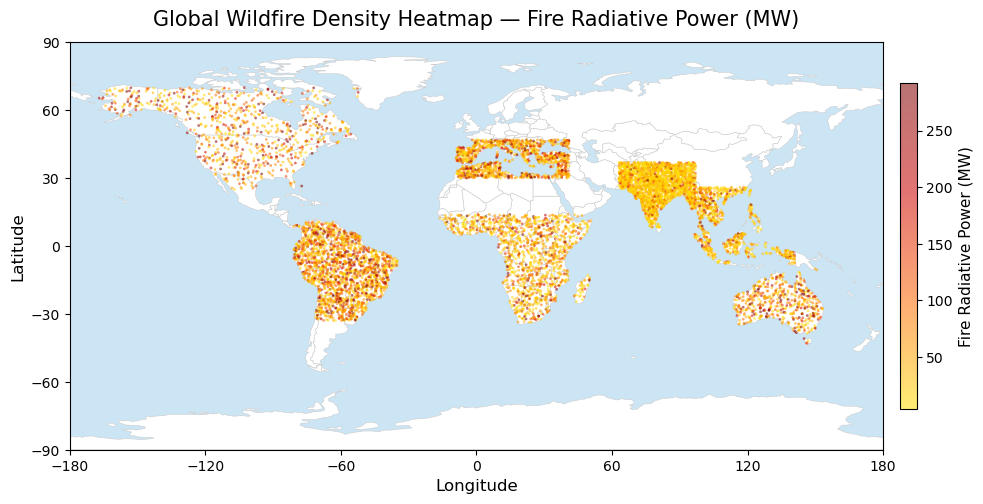

In [4]:
#Creating a global heatmap (latitude-longitude Density Map)
#Loading world basemap 
try: world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
except Exception:                             
    world = gpd.read_file('https://naciscdn.org/naturalearth/110m/cultural/ne_110m_admin_0_countries.zip')

#Converting fire detections to GeoDataFrame 
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(df['longitude'], df['latitude']), crs='EPSG:4326')
if world.crs != gdf.crs:
    world = world.to_crs(gdf.crs)

#Keeping only points that fall inside a country
fires_clipped = gpd.sjoin(gdf, world[['geometry']], how='inner', predicate='within')

#Creating color map for fire intensity
fire_cmap = LinearSegmentedColormap.from_list('fire_vivid', ['#FFE000', '#FF6600', '#CC0000', '#7F0000'])

# Plotting the global wildfire density heatmap
fig, ax = plt.subplots(figsize=(10, 5))
ax.set_facecolor('#cce5f5')

world.plot(ax=ax, color='white', edgecolor='#cccccc', linewidth=0.4)
sc = ax.scatter(fires_clipped['longitude'],  fires_clipped['latitude'], c=fires_clipped['frp_mw'],
    cmap=fire_cmap, s=4, alpha=0.55, vmin=fires_clipped['frp_mw'].quantile(0.05),
    vmax=fires_clipped['frp_mw'].quantile(0.95), linewidths=0, rasterized=True)

cbar = plt.colorbar(sc, ax=ax, fraction=0.025, pad=0.02, shrink=0.8)
cbar.set_label('Fire Radiative Power (MW)', fontsize=11)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Global Wildfire Density Heatmap — Fire Radiative Power (MW)', fontsize=15, pad=12)
ax.set_xticks(range(-180, 181, 60))
ax.set_yticks(range(-90, 91, 30))

print(f"Total fire detections (clipped to land): {len(fires_clipped):,} / {len(df):,}")
plt.tight_layout()
plt.show()

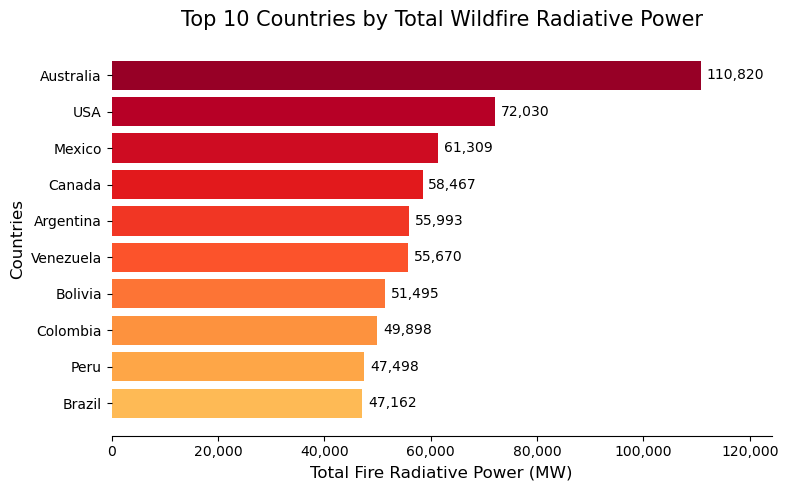

In [5]:
#Creating a Top 10 countries bar chart for total wildfire activity
top10 = (df.groupby('country')['frp_mw'].sum().nlargest(10).sort_values().reset_index())
top10.columns = ['Country', 'Total FRP (MW)']

#Creating the bar chart
fig, ax = plt.subplots(figsize=(8, 5))
colors = plt.cm.YlOrRd(np.linspace(0.35, 0.95, len(top10)))
bars = ax.barh(top10['Country'], top10['Total FRP (MW)'], color=colors, edgecolor='none')

#Adding labels to the bars
for bar in bars:
    w = bar.get_width()
    ax.text(w + top10['Total FRP (MW)'].max() * 0.01, bar.get_y() + bar.get_height() / 2,
            f'{w:,.0f}', va='center', fontsize=10)

#Customizing the plot
ax.set_xlabel('Total Fire Radiative Power (MW)', fontsize=12)
ax.set_ylabel('Countries', fontsize=12)
ax.set_title('Top 10 Countries by Total Wildfire Radiative Power', fontsize=15, pad=12)
ax.xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
ax.set_xlim(0, top10['Total FRP (MW)'].max() * 1.12)
sns.despine(ax=ax, left=True, bottom=False)

plt.tight_layout()
plt.show()

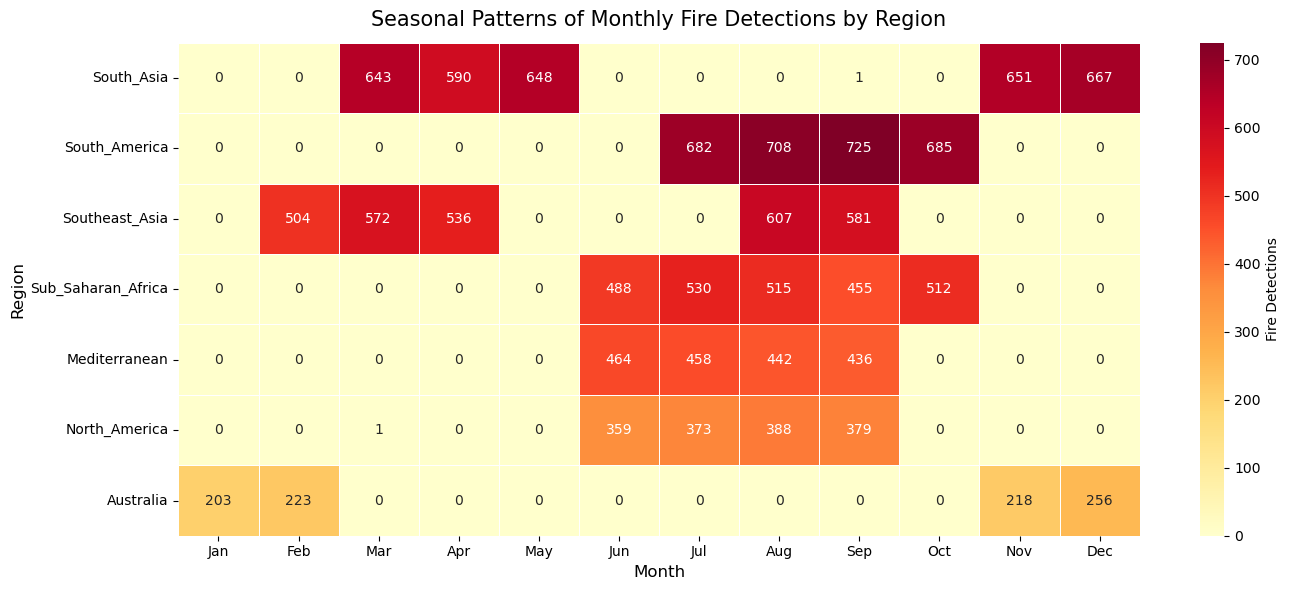

In [6]:
#Creating Monthly Fire Count Heatmap by Region 
df['acq_date'] = pd.to_datetime(df['acq_date'])
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

#Creating a pivot table for the heatmap
hm = (df.assign(month_num=df['acq_date'].dt.month).groupby(['region', 'month_num']).size().unstack(fill_value=0))
hm.columns = [month_labels[m - 1] for m in hm.columns]
hm = hm[[m for m in month_labels if m in hm.columns]]  

#Sorting rows by total fire count descending
hm = hm.loc[hm.sum(axis=1).sort_values(ascending=False).index]

#Plotting the heatmap
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    hm, cmap='YlOrRd', annot=True, fmt='d',
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Fire Detections'},
    ax=ax
)
ax.set_title('Seasonal Patterns of Monthly Fire Detections by Region',
             fontsize=15, pad=12)
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

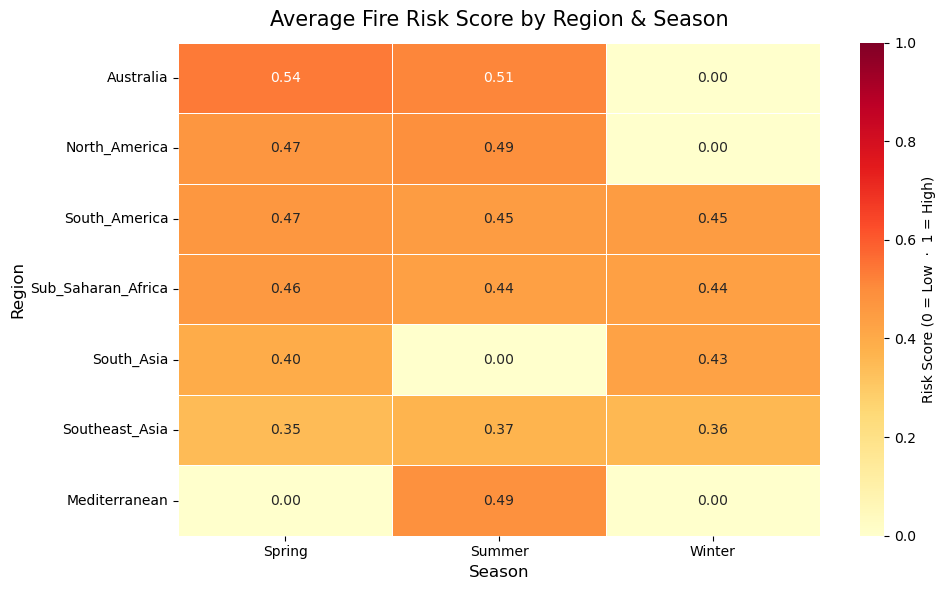

In [7]:
#Creating Average Fire Risk Score Heatmap by Region and Season
risk_fc = df[['region', 'season', 'temp_max_c', 'wind_max_kmh','frp_mw', 'precip_mm', 'humidity_pct']].copy()

#Scaling numeric columns
_scaler = MinMaxScaler()
for col in ['temp_max_c', 'wind_max_kmh', 'frp_mw']:
    risk_fc[col + '_n'] = _scaler.fit_transform(risk_fc[[col]])
for col in ['precip_mm', 'humidity_pct']:
    risk_fc[col + '_n'] = 1 - _scaler.fit_transform(risk_fc[[col]])

#Calculating risk score as the average of normalized factors
risk_fc['risk_score'] = risk_fc[['temp_max_c_n', 'wind_max_kmh_n', 'frp_mw_n', 'precip_mm_n', 'humidity_pct_n']].mean(axis=1)
pivot = risk_fc.groupby(['region', 'season'])['risk_score'].mean().unstack()
season_order = [s for s in ['Spring', 'Summer', 'Fall', 'Winter'] if s in pivot.columns]
pivot = pivot[season_order].sort_values(season_order[0], ascending=False)

#Filling no region-season detections with 0
pivot = pivot.fillna(0)

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.2f', linewidths=0.5, linecolor='white',
    vmin=0, vmax=1, cbar_kws={'label': 'Risk Score (0 = Low  ·  1 = High)'}, ax=ax)

ax.set_title('Average Fire Risk Score by Region & Season',
             fontsize=15, pad=12)
ax.set_xlabel('Season', fontsize=12)
ax.set_ylabel('Region', fontsize=12)
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

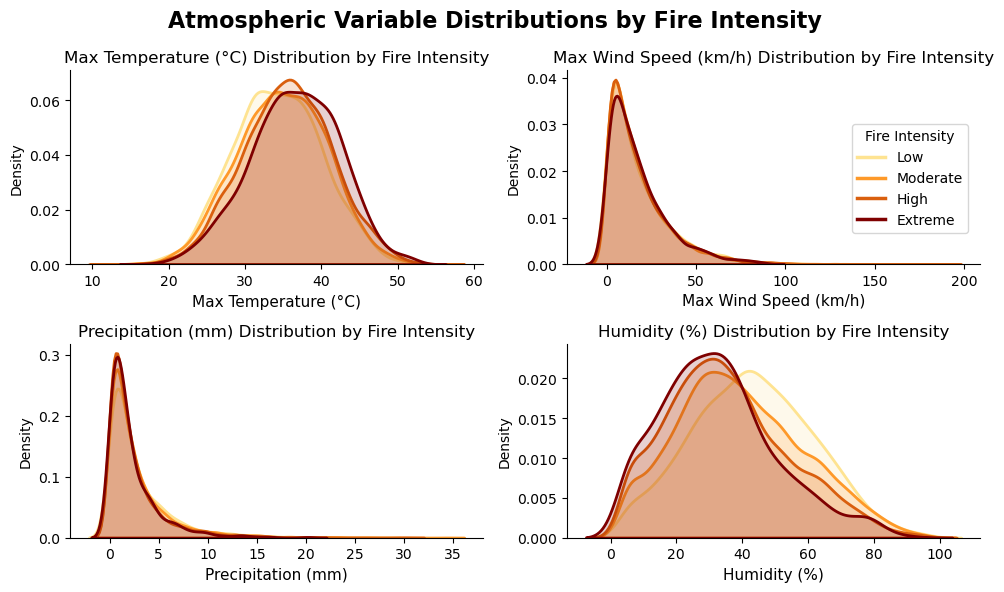

In [8]:
#Creating a KDE Distributions of each Atmospheric Variable by Fire Intensity
atm_vars = [('temp_max_c',   'Max Temperature (°C)'), ('wind_max_kmh', 'Max Wind Speed (km/h)'),
    ('precip_mm',    'Precipitation (mm)'), ('humidity_pct', 'Humidity (%)')]

#Defining fire intensity categories
intensity_order = ['Low', 'Moderate', 'High', 'Extreme']
colors = {'Low': '#fee391', 'Moderate': '#fe9929', 'High': '#d95f0e', 'Extreme': '#7f0000'}

#Creating the KDE plots
fig, axes = plt.subplots(2, 2, figsize=(10, 6))
axes = axes.flatten()

#Iterating through each atmospheric variable 
for ax, (col, label) in zip(axes, atm_vars):
    for intensity in intensity_order:
        sub = df[df['fire_intensity'] == intensity][col]
        sns.kdeplot(sub, ax=ax, color=colors[intensity], linewidth=2, fill=True, alpha=0.18)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Density', fontsize=10)
    ax.set_title(f'{label} Distribution by Fire Intensity', fontsize=12)
    sns.despine(ax=ax)

#Adding one shared legend for the entire figure
handles = [plt.Line2D([0], [0], color=colors[i], linewidth=2.5, label=i)
           for i in intensity_order]
fig.legend(handles=handles, title='Fire Intensity', title_fontsize=10,
           fontsize=10, loc='upper right', bbox_to_anchor=(0.98, 0.80), frameon=True)

fig.suptitle('Atmospheric Variable Distributions by Fire Intensity',
             fontsize=16, fontweight='bold', x=0.5, ha='center')
plt.tight_layout()
plt.show()